In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="pSM0gizCKdNnlYVecoKk")
project = rf.workspace("bhaswanths-workspace-krsji").project("my-first-project-ogpvt")
version = project.version(2)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 33.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.4 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery


Extracting Dataset Version Zip to My-First-Project-2 in coco:: 100%|██████████| 22328/22328 [00:03<00:00, 6565.48it/s]


In [3]:
import os, cv2, time, torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor

from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from pycocotools.coco import COCO
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class COCODataset(Dataset):

    def __init__(self, img_dir, ann_file):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)

        self.ids = [i for i in self.coco.imgs.keys()
                    if len(self.coco.getAnnIds(imgIds=i)) > 0]

        cat_ids = self.coco.getCatIds()
        self.cat2label = {cat_id:i+1 for i,cat_id in enumerate(cat_ids)}

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, img_info["file_name"])

        img = cv2.imread(path)
        img = cv2.resize(img, (512,512))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))

        boxes, labels = [], []
        for ann in anns:
            x,y,w,h = ann["bbox"]
            if w>0 and h>0:
                boxes.append([x,y,x+w,y+h])
                labels.append(self.cat2label[ann["category_id"]])

        return ToTensor()(img), {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

def collate_fn(batch):
    return tuple(zip(*batch))

In [5]:
BASE = "/kaggle/working/My-First-Project-2"

train_dataset = COCODataset(BASE+"/train", BASE+"/train/_annotations.coco.json")
val_dataset   = COCODataset(BASE+"/valid", BASE+"/valid/_annotations.coco.json")
test_dataset  = COCODataset(BASE+"/test", BASE+"/test/_annotations.coco.json")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

NUM_CLASSES = len(train_dataset.cat2label) + 1
print("Classes:", NUM_CLASSES)

loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Classes: 18


In [6]:
model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 146MB/s] 


In [7]:
def evaluate_model(model, loader):

    model.eval()
    metric = MeanAveragePrecision()

    TP=FP=FN=0
    total_loss = 0
    count = 0

    with torch.no_grad():
        for images, targets in loader:

            images = [img.to(DEVICE) for img in images]
            targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

            # loss
            model.train()
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            total_loss += loss.item()
            count += 1
            model.eval()

            outputs = model(images)

            preds, gts = [], []

            for i in range(len(outputs)):

                pred_boxes = outputs[i]["boxes"].cpu()
                pred_scores = outputs[i]["scores"].cpu()
                pred_labels = outputs[i]["labels"].cpu()

                gt_boxes = targets[i]["boxes"].cpu()
                gt_labels = targets[i]["labels"].cpu()

                preds.append({"boxes": pred_boxes,"scores": pred_scores,"labels": pred_labels})
                gts.append({"boxes": gt_boxes,"labels": gt_labels})

                keep = pred_scores >= 0.5
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                matched = set()

                for pb, pl in zip(pred_boxes, pred_labels):
                    found=False
                    for j,(gb,gl) in enumerate(zip(gt_boxes,gt_labels)):
                        if j in matched or pl!=gl:
                            continue

                        iou = box_iou(pb.unsqueeze(0), gb.unsqueeze(0))[0][0]

                        if iou >= 0.5:
                            TP+=1
                            matched.add(j)
                            found=True
                            break

                    if not found:
                        FP+=1

                FN += len(gt_boxes)-len(matched)

            metric.update(preds, gts)

    res = metric.compute()

    precision = TP/(TP+FP+1e-6)
    recall = TP/(TP+FN+1e-6)
    f1 = 2*(precision*recall)/(precision+recall+1e-6)

    avg_loss = total_loss / (count + 1e-6)

    return {
        "mAP": res["map"].item(),
        "mAP@0.5": res["map_50"].item(),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Loss": avg_loss
    }

In [8]:
EPOCHS = 15

train_losses, val_losses, test_losses = [], [], []
train_maps, val_maps, test_maps = [], [], []

start = time.time()

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    epoch_loss = 0

    for images, targets in tqdm(train_loader):

        images = [img.to(DEVICE) for img in images]
        targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            loss = sum(model(images, targets).values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_res = evaluate_model(model, train_loader)
    val_res   = evaluate_model(model, val_loader)
    test_res  = evaluate_model(model, test_loader)

    train_maps.append(train_res["mAP@0.5"])
    val_maps.append(val_res["mAP@0.5"])
    test_maps.append(test_res["mAP@0.5"])

    val_losses.append(val_res["Loss"])
    test_losses.append(test_res["Loss"])

    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {val_res['Loss']:.4f}")
    print(f"Test Loss: {test_res['Loss']:.4f}")
    print(f"Test mAP@0.5: {test_res['mAP@0.5']:.4f}")

print("\n⏱ Total Training Time:", time.time()-start)




Epoch 1/15


100%|██████████| 6483/6483 [08:03<00:00, 13.41it/s]


Train Loss: 0.8539
Val Loss: 0.7962
Test Loss: 0.7885
Test mAP@0.5: 0.7650

Epoch 2/15


100%|██████████| 6483/6483 [07:47<00:00, 13.88it/s]


Train Loss: 0.7268
Val Loss: 0.8383
Test Loss: 0.8076
Test mAP@0.5: 0.7918

Epoch 3/15


...

Train Loss: 0.5455
Val Loss: 0.9241
Test Loss: 0.9398
Test mAP@0.5: 0.8472

Epoch 14/15


100%|██████████| 6483/6483 [07:38<00:00, 14.14it/s]


Train Loss: 0.5265
Val Loss: 0.9540
Test Loss: 0.9823
Test mAP@0.5: 0.8186

Epoch 15/15


100%|██████████| 6483/6483 [07:33<00:00, 14.28it/s]


Train Loss: 0.5315
Val Loss: 1.0540
Test Loss: 1.1799
Test mAP@0.5: 0.8436

⏱ Total Training Time: 20430.647191286087


In [9]:
torch.save({
    "model_state_dict":model.state_dict(),
    "num_classes":NUM_CLASSES
},"fasterrcnnfinal_1.pth")

In [10]:

results = evaluate_model(model, train_loader)

print("\nFINAL RESULTS")
print("mAP@0.5:0.95:", results["mAP"])
print("mAP@0.5:", results["mAP@0.5"])
print("Precision:", results["Precision"])
print("Recall:", results["Recall"])
print("F1:", results["F1"])


FINAL RESULTS
mAP@0.5:0.95: 0.7562094330787659
mAP@0.5: 0.9462866187095642
Precision: 0.9433823111735756
Recall: 0.9634973056976941
F1: 0.9533332155318304


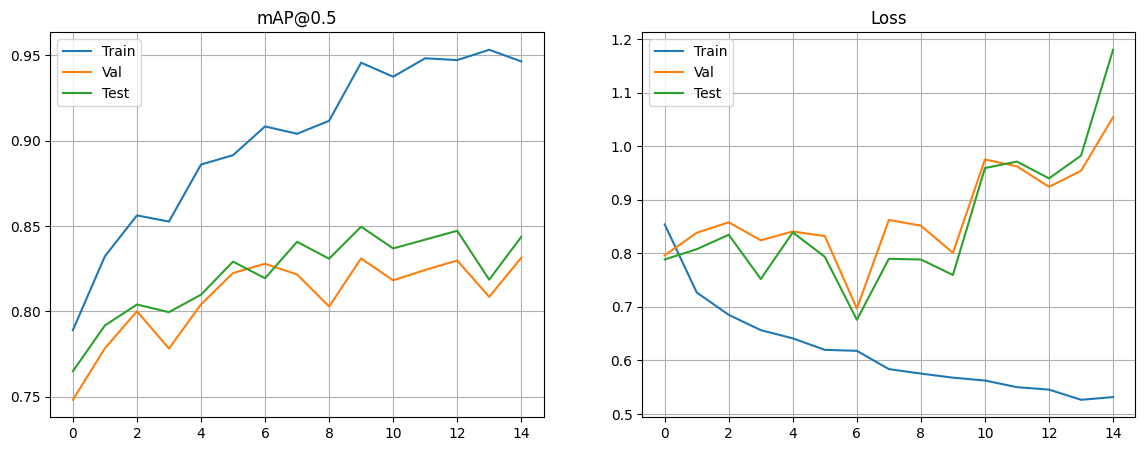

In [11]:
epochs = range(len(train_losses))

plt.figure(figsize=(14,5))

# mAP
plt.subplot(1,2,1)
plt.plot(epochs, train_maps, label="Train")
plt.plot(epochs, val_maps, label="Val")
plt.plot(epochs, test_maps, label="Test")
plt.title("mAP@0.5")
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, val_losses, label="Val")
plt.plot(epochs, test_losses, label="Test")
plt.title("Loss")
plt.legend()
plt.grid()

plt.show()

In [25]:
from torchvision.ops import box_iou
import numpy as np
import torch

def compute_cm(model, loader, num_classes, iou_thresh=0.5, score_thresh=0.5):

    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.float32)

    with torch.no_grad():
        for images, targets in loader:

            images = [img.to(DEVICE) for img in images]
            outputs = model(images)

            for i in range(len(outputs)):

                pred_boxes = outputs[i]["boxes"].cpu()
                pred_scores = outputs[i]["scores"].cpu()
                pred_labels = outputs[i]["labels"].cpu()

                gt_boxes = targets[i]["boxes"]
                gt_labels = targets[i]["labels"]

                # ✅ Apply confidence threshold
                keep = pred_scores >= score_thresh
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                matched_gt = set()

                # ✅ Match predictions → GT (1-to-1)
                for pb, pl in zip(pred_boxes, pred_labels):

                    best_iou = 0
                    best_j = -1

                    for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):

                        if j in matched_gt:
                            continue  # prevent duplicate matching

                        iou = box_iou(pb.unsqueeze(0), gb.unsqueeze(0))[0][0]

                        if iou > best_iou:
                            best_iou = iou
                            best_j = j

                    if best_iou >= iou_thresh:
                        cm[gt_labels[best_j].item()][pl.item()] += 1
                        matched_gt.add(best_j)
                    else:
                        cm[0][pl.item()] += 1  # False Positive

                # ✅ Remaining GT = False Negatives
                for j, gl in enumerate(gt_labels):
                    if j not in matched_gt:
                        cm[gl.item()][0] += 1

    return cm

In [26]:
def normalize_cm(cm):
    cm = cm.astype(np.float32)
    row_sum = cm.sum(axis=1, keepdims=True)

    # Avoid division by zero
    cm_norm = np.divide(cm, row_sum, where=row_sum != 0)

    return cm_norm

In [27]:
cm = compute_cm(model, test_loader, NUM_CLASSES)
cm_norm = normalize_cm(cm)

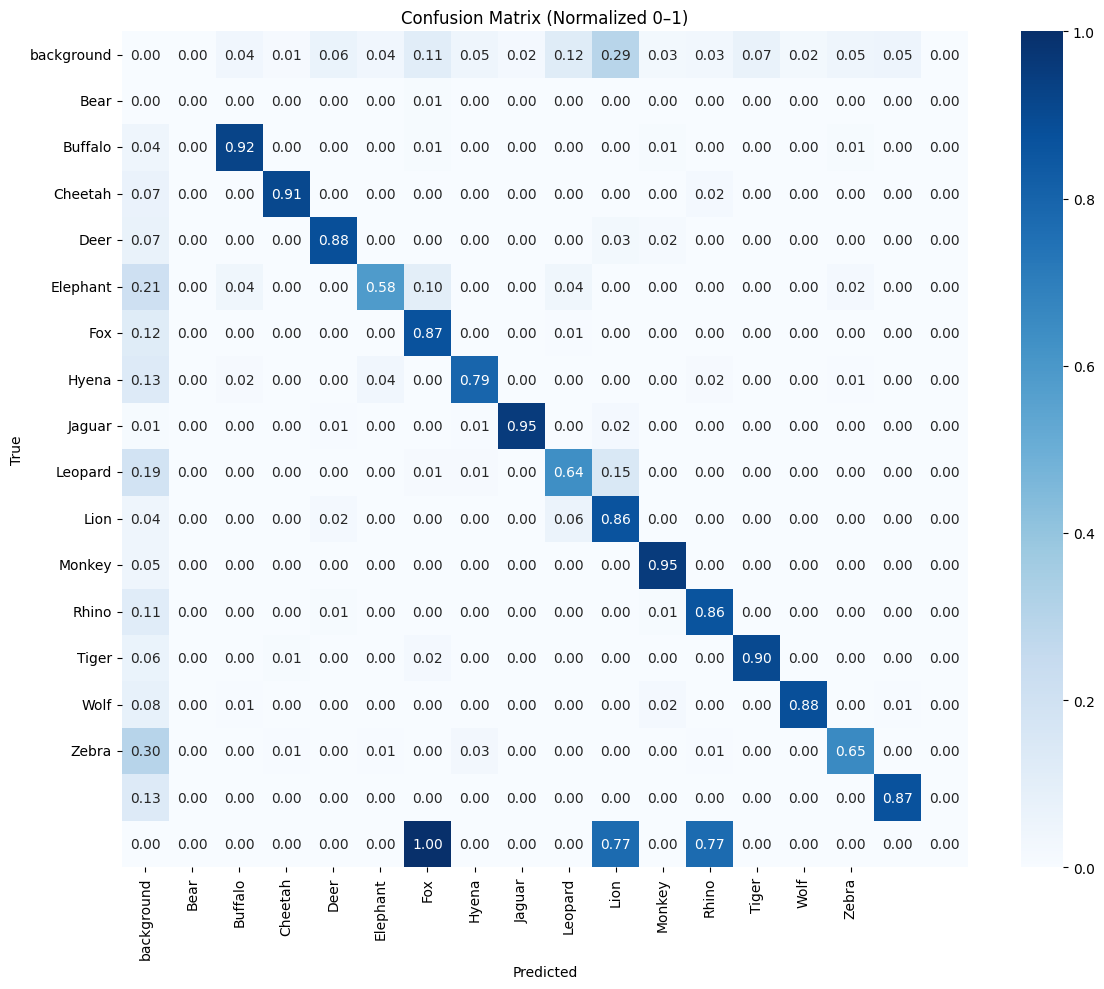

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
"background","Bear","Buffalo","Cheetah","Deer","Elephant","Fox",
"Hyena","Jaguar","Leopard","Lion","Monkey","Rhino","Tiger","Wolf","Zebra"
]

plt.figure(figsize=(12,10))

sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized 0–1)")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# ================= DEFINE CLASSES =================
CLASSES = [
"__background__",
"Bear","Buffalo","Jaguar","Cheetah","Deer","Elephant","Fox",
"Hyena","Leopard","Lion","Monkey","Rhino","Tiger","Wolf","Zebra"
]

In [14]:
import time

def test_image(image_path, score_threshold=0.5):

    img = cv2.imread(image_path)

    if img is None:
        print("Image not found:", image_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tensor = ToTensor()(img).to(DEVICE)

    # ================= START TIMER =================
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        prediction = model([tensor])[0]

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.time()
    inference_time = end_time - start_time
    # ================= END TIMER =================

    boxes = prediction["boxes"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()
    labels = prediction["labels"].cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):

        if score < score_threshold:
            continue

        x1, y1, x2, y2 = map(int, box)
        class_name = CLASSES[label]

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            img,
            f"{class_name} {score:.2f}",
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    # ================= SHOW IMAGE =================
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Prediction Output")

    # ================= PRINT TIME =================
    print(f"\n⏱ Prediction Time: {inference_time:.4f} seconds")



⏱ Prediction Time: 0.0206 seconds
⚡ FPS: 48.61


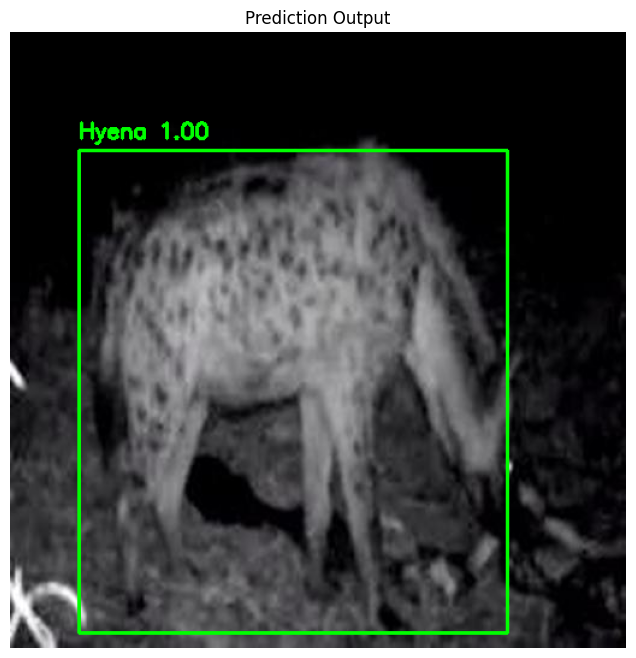

In [15]:
test_image("/kaggle/working/My-First-Project-2/test/000000000136_jpg.rf.3be2fc8c71b50a02f64ab3bdd7c02904.jpg")


⏱ Prediction Time: 0.0203 seconds
⚡ FPS: 49.22


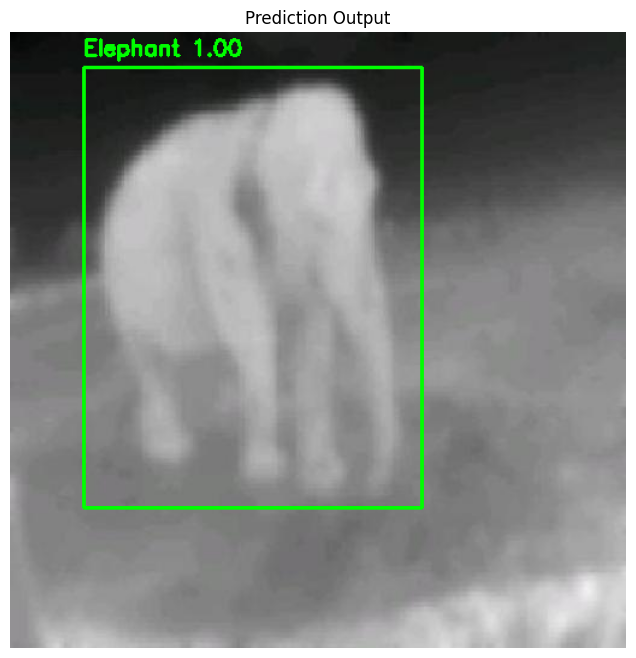

In [16]:
test_image("/kaggle/working/My-First-Project-2/test/00037_result_8_png_jpg.rf.6159ab0032a6b96dc754a4b976729df8.jpg")


⏱ Prediction Time: 0.0200 seconds
⚡ FPS: 50.05


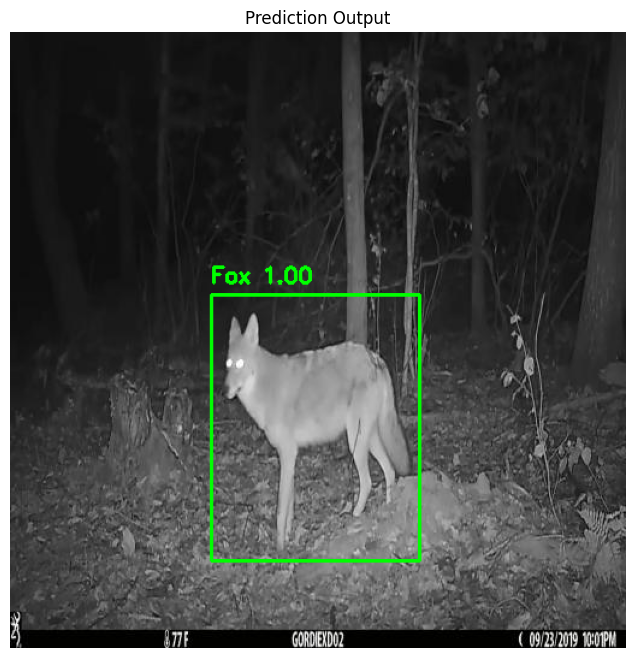

In [17]:
test_image("/kaggle/working/My-First-Project-2/test/animals_mp4-563_jpg.rf.2b81f1c3892cfa9001859c4ae4adb387.jpg")